In [1]:
%run import_libs.py

In [ ]:
rejected_participants = ['323'] #posthocly defining it here so that we can get the demographic data from the included participants 

# Participant demographics

In [ ]:
root = "D:/yueying/gazeObject_YueyingDong/" 
pathpy = root + "results/data/psychopy/*.csv" #change this to the psychopy repository
pathIrb = root + "irb_clean.csv" #this is under the main folder

In [3]:
irb= pd.read_csv(pathIrb)

In [4]:
psyFull = pd.DataFrame()
for f in glob.glob(pathpy)[:]:
    

    trlInfo = pd.read_csv(f)
    try:
        trlInfo = trlInfo[(trlInfo.is_practice!=True)& (trlInfo.TRIALID.isnull() == False)]
    except AttributeError:
        trlInfo = trlInfo[(trlInfo.TRIALID.isnull() == False)]
        
    psyFull = pd.concat([psyFull,trlInfo])
psyFull = psyFull.drop_duplicates().reset_index(drop = True)

In [11]:
irb['dob_clean'] = pd.to_datetime(irb.dob,format='mixed',errors='coerce')
current_date = datetime.now()

birthdate = irb['dob_clean'] 
irb ['age']= [current_date.year - birthdate.year - ((current_date.month, current_date.day) < (birthdate.month, birthdate.day)) for birthdate in irb['dob_clean'] ]
irb = irb[~irb['subject id (the experimenter will fill in this)'].isin(rejected_participants)]

exp1  =irb[irb['subject id (the experimenter will fill in this)'] < 360]
exp2 = irb[irb['subject id (the experimenter will fill in this)'] >= 360]

In [12]:
exp1.age.min(),exp1.age.max(),exp1.age.mean(),exp1.age.std(),

(21.0, 33.0, 23.756756756756758, 2.8225816138717703)

In [13]:
exp2.age.min(),exp2.age.max(),exp2.age.mean(),exp2.age.std(),

(19.0, 33.0, 21.58974358974359, 2.4139719258598276)

In [14]:
exp1.gender.value_counts()

gender
female       24
male          8
Male          4
Female        3
Nonbinary     1
decline       1
Name: count, dtype: int64

In [15]:
exp2.gender.value_counts()

gender
female        26
Female         8
male           5
non-binary     1
decline        1
Name: count, dtype: int64

# Figure 1D

In [ ]:
# grab relevant columns from psyFull and create task column for analysis
trlInfo = psyFull[['trlType', 'corrAns','stimImage','TRIALID','rspThisTrl', 'rtThisTrl']]
trlInfo['subj'] = [ast.literal_eval(i)[0] for i in psyFull.TRIALID]
trlInfo['corrAns_text'] = np.where(psyFull.corrAns == 0,'same','diff')
trlInfo['rspErr'] = trlInfo.rspThisTrl == trlInfo.corrAns_text
trlInfo['task'] = ['precue' if int(i) < 360 else 'retrocue' for i in trlInfo.subj]


trlInfo = trlInfo[
        (trlInfo.rspThisTrl.isnull() == False) & # no missing response
        (trlInfo.rtThisTrl > 0) & # valid RT (e.g. < 0, psychopy sometimes does that)
        (~trlInfo.subj.isin(rejected_participants))
        ].reset_index(drop=True)

trlInfo['rtLogTrans'] = np.log(trlInfo.rtThisTrl)
subjMean = trlInfo.groupby(['subj','trlType','task']).mean(['rspErr','rtThisTrl','rtLogTrans']).reset_index()

### response err

In [19]:
print(subjMean[(subjMean.task =='precue') &(subjMean.trlType == 'verbal')].rspErr.mean() * 100,
subjMean[(subjMean.task =='precue') &(subjMean.trlType == 'verbal')].rspErr.std() * 100)

print(subjMean[(subjMean.task =='retrocue') &(subjMean.trlType == 'verbal')].rspErr.mean() * 100,
subjMean[(subjMean.task =='retrocue') &(subjMean.trlType == 'verbal')].rspErr.std() * 100)

94.286462633518 4.648495148860484
93.22913651011827 6.596840628989184


In [20]:
print(subjMean[(subjMean.task =='precue') &(subjMean.trlType == 'visual')].rspErr.mean()* 100,
subjMean[(subjMean.task =='precue') &(subjMean.trlType == 'visual')].rspErr.std()* 100)

print(subjMean[(subjMean.task =='retrocue') &(subjMean.trlType == 'visual')].rspErr.mean()* 100,
subjMean[(subjMean.task =='retrocue') &(subjMean.trlType == 'visual')].rspErr.std()* 100)

87.37092880221395 7.641923404150347
85.5194510643289 10.766756413471812


In [18]:
print(stats.ttest_rel(subjMean[(subjMean.task =='precue') &(subjMean.trlType == 'visual')].rspErr,
                subjMean[(subjMean.task =='precue') &(subjMean.trlType == 'verbal')].rspErr,        
                        nan_policy='omit'),'\n',
stats.ttest_rel(subjMean[(subjMean.task =='retrocue') &(subjMean.trlType == 'visual')].rspErr,
                subjMean[(subjMean.task =='retrocue') &(subjMean.trlType == 'verbal')].rspErr,        
                        nan_policy='omit'))

TtestResult(statistic=-8.943350332980955, pvalue=4.3650764199185254e-11, df=40) 
 TtestResult(statistic=-5.693408926340218, pvalue=1.274692706240397e-06, df=40)


In [19]:
print('response error \n----------')

print('precue, cohen d:', cohenD(subjMean[(subjMean.task =='precue') &(subjMean.trlType == 'visual')].rspErr,
       subjMean[(subjMean.task =='precue') &(subjMean.trlType == 'verbal')].rspErr))

print('retrocue, cohen d:', cohenD(subjMean[(subjMean.task =='retrocue') &(subjMean.trlType == 'visual')].rspErr,
       subjMean[(subjMean.task =='retrocue') &(subjMean.trlType == 'verbal')].rspErr))

response error 
----------
precue, cohen d: -1.0933906524880481
retrocue, cohen d: -0.8634777987140155


### rt

In [20]:
print(subjMean[(subjMean.task =='precue') &(subjMean.trlType == 'verbal')].rtThisTrl.mean(),
subjMean[(subjMean.task =='precue') &(subjMean.trlType == 'verbal')].rtThisTrl.std())

print(subjMean[(subjMean.task =='retrocue') &(subjMean.trlType == 'verbal')].rtThisTrl.mean(),
subjMean[(subjMean.task =='retrocue') &(subjMean.trlType == 'verbal')].rtThisTrl.std())

0.9329846256368586 0.19792336105236524
0.9422662418088132 0.159423274021073


In [21]:
print(subjMean[(subjMean.task =='precue') &(subjMean.trlType == 'visual')].rtThisTrl.mean(),
subjMean[(subjMean.task =='precue') &(subjMean.trlType == 'visual')].rtThisTrl.std())

print(subjMean[(subjMean.task =='retrocue') &(subjMean.trlType == 'visual')].rtThisTrl.mean(),
subjMean[(subjMean.task =='retrocue') &(subjMean.trlType == 'visual')].rtThisTrl.std())

0.9902756474366033 0.20228363389109458
1.0056341706820606 0.18574876005070654


In [22]:
print(stats.ttest_rel(subjMean[(subjMean.task =='precue') &(subjMean.trlType == 'visual')].rtThisTrl,
                subjMean[(subjMean.task =='precue') &(subjMean.trlType == 'verbal')].rtThisTrl,        
                        nan_policy='omit'),'\n',
stats.ttest_rel(subjMean[(subjMean.task =='retrocue') &(subjMean.trlType == 'visual')].rtThisTrl,
                subjMean[(subjMean.task =='retrocue') &(subjMean.trlType == 'verbal')].rtThisTrl,        
                        nan_policy='omit'))

TtestResult(statistic=4.977044097675633, pvalue=1.2738397672508093e-05, df=40) 
 TtestResult(statistic=4.8863437258262135, pvalue=1.6996301945081186e-05, df=40)


In [23]:
print('rt \n----------')

print('precue, cohen d:', cohenD(subjMean[(subjMean.task =='precue') &(subjMean.trlType == 'visual')].rtThisTrl,
       subjMean[(subjMean.task =='precue') &(subjMean.trlType == 'verbal')].rtThisTrl))

print('retrocue, cohen d:', cohenD(subjMean[(subjMean.task =='retrocue') &(subjMean.trlType == 'visual')].rtThisTrl,
       subjMean[(subjMean.task =='retrocue') &(subjMean.trlType == 'verbal')].rtThisTrl))

rt 
----------
precue, cohen d: 0.28628995768313714
retrocue, cohen d: 0.3661039978135439


### precue vs retrocue

In [21]:
subjMeanAgg = trlInfo.groupby(['subj','task']).mean(['rspErr','rtThisTrl']).reset_index()

In [22]:
print('response err \n-------')

print(stats.ttest_ind(subjMeanAgg[(subjMeanAgg.task =='precue') ].rspErr,
                subjMeanAgg[(subjMeanAgg.task =='retrocue') ].rspErr,        
                        nan_policy='omit'),'\n',)

print('cohen d:',
    cohenD(subjMeanAgg[(subjMeanAgg.task =='precue') ].rspErr,
                subjMeanAgg[(subjMeanAgg.task =='retrocue') ].rspErr)
)

response err 
-------
TtestResult(statistic=0.959551888276432, pvalue=0.34017191976435646, df=80.0) 

cohen d: 0.21192955874073408


In [23]:
print('rt \n-------')

print(stats.ttest_ind(subjMeanAgg[(subjMeanAgg.task =='precue') ].rtThisTrl,
                subjMeanAgg[(subjMeanAgg.task =='retrocue') ].rtThisTrl,        
                        nan_policy='omit'),'\n',)

print('cohen d:',
    cohenD(subjMeanAgg[(subjMeanAgg.task =='precue') ].rtThisTrl,
                subjMeanAgg[(subjMeanAgg.task =='retrocue') ].rtThisTrl)
)

rt 
-------
TtestResult(statistic=-0.30451701817190874, pvalue=0.7615247793549474, df=80.0) 

cohen d: -0.06725655806497129


In [24]:
subjMean['rspErr'] = np.round(subjMean.rspErr *100,2)

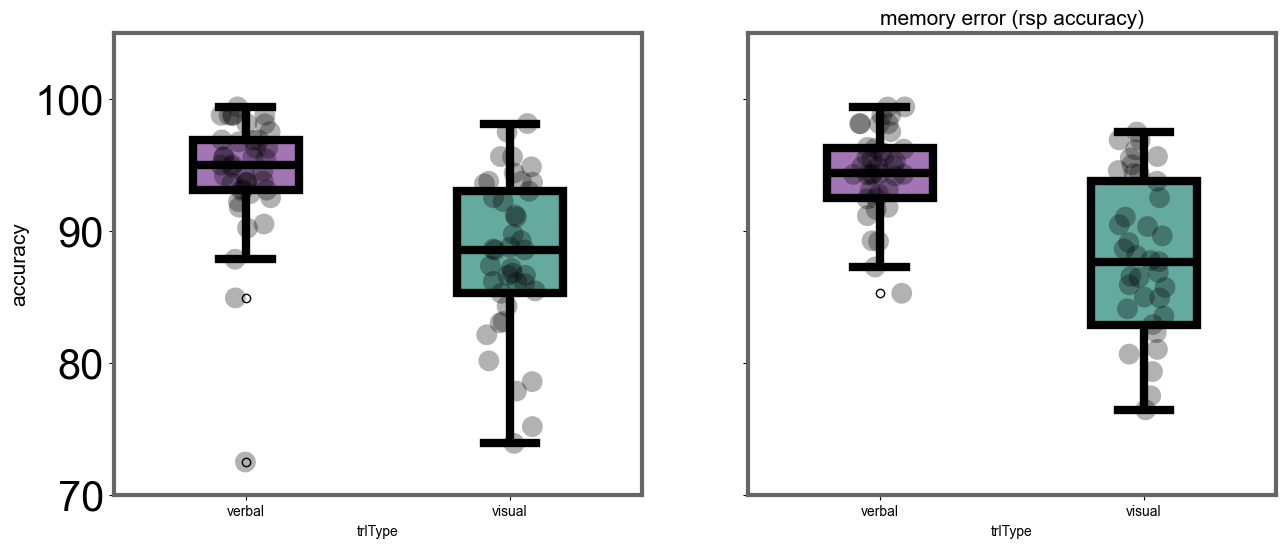

In [25]:
fs(15,6)

fig,ax = plt.subplots(ncols = 2,sharex=True,sharey=True)
sns.stripplot(x = 'trlType',y = 'rspErr',palette=['black'],zorder=10, marker = "o",s = 15,alpha = 0.3,
              data = subjMean[subjMean.task =='precue'],ax = ax[0])


sns.boxplot(x = 'trlType',y = 'rspErr',palette=['#a86ac0','#59b5a6'],width = 0.4,linecolor = 'black',
                linewidth=6,data = subjMean[subjMean.task =='precue'],ax = ax[0])


sns.stripplot(x = 'trlType',y = 'rspErr',s = 15,palette=['black'],zorder=10,alpha = 0.3,
               marker = "o",data = subjMean[subjMean.task =='retrocue'],ax = ax[1])

sns.boxplot(x = 'trlType',y = 'rspErr',linewidth = 6,width = 0.4,linecolor = 'black',
            palette=['#a86ac0','#59b5a6'],data = subjMean[subjMean.task =='retrocue'],ax = ax[1])

plt.gca().yaxis.set_major_locator(ticker.MultipleLocator(10))

for a in ax:
    for spine in a.spines.values():
        spine.set_color('#666666')
        spine.set_linewidth(3)
plt.ylim(70,105)

plt.title('memory error (rsp accuracy)',fontsize = 15)
ax[0].set_ylabel('accuracy',fontsize = 15)
#plt.xlabel('condition',fontsize = 15)
ax[0].tick_params(axis='y', which='major', labelsize=30)
#plt.tight_layout()


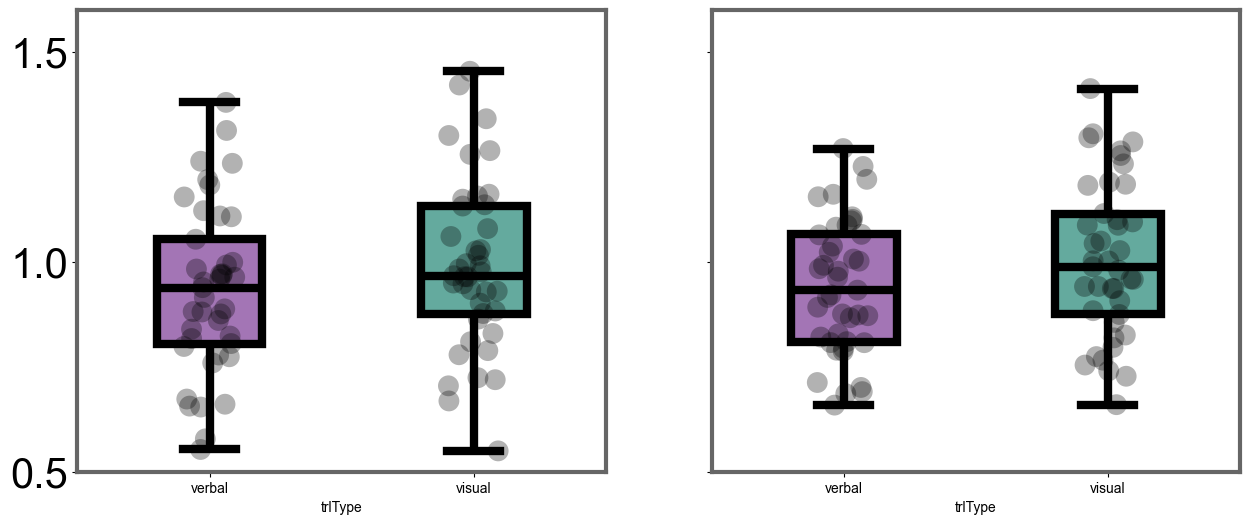

In [26]:
fs(15,6)

fig,ax = plt.subplots(ncols = 2,sharex=True,sharey=True)
sns.stripplot(x = 'trlType',y = 'rtThisTrl',s = 15,alpha = 0.3,palette=['black'],zorder=10, marker = "o",
              data = subjMean[subjMean.task =='precue'],ax = ax[0])


sns.boxplot(x = 'trlType',y = 'rtThisTrl',palette=['#a86ac0','#59b5a6'],linecolor = 'black',
                linewidth = 6,width = 0.4,data = subjMean[subjMean.task =='precue'],ax = ax[0])


sns.stripplot(x = 'trlType',y = 'rtThisTrl',s = 15,alpha = 0.3,palette=['black'],zorder=10, marker = "o",data = subjMean[subjMean.task =='retrocue'],ax = ax[1])


sns.boxplot(x = 'trlType',y = 'rtThisTrl',linewidth = 6,width = 0.4,linecolor = 'black',
            palette=['#a86ac0','#59b5a6'],data = subjMean[subjMean.task =='retrocue'],ax = ax[1])

plt.gca().yaxis.set_major_locator(ticker.MultipleLocator(0.5))
for a in ax:
    for spine in a.spines.values():
        spine.set_color('#666666')
        spine.set_linewidth(3)
plt.ylim(0.5,1.6)
plt.title('',fontsize = 15)
ax[0].set_ylabel('',fontsize = 15)
#plt.xlabel('condition',fontsize = 15)
ax[0].tick_params(axis='y', which='major', labelsize=30)


# Figure 3F

In [158]:
precuePup = pd.read_csv(f"{root}results/data/pupClean/cleanPup_311to352.csv").iloc[:,1:]
precuePup['participant'] = [ast.literal_eval(i)[0] for i in precuePup.TRIALID]

In [159]:
retrocuePup = pd.read_csv(f"{root}results/data/pupClean/cleanPup_360to400.csv").iloc[:,1:]
retrocuePup['participant'] = [ast.literal_eval(i)[0] for i in retrocuePup.TRIALID]

In [185]:
precuePup_Norm = precuePup.iloc[:,501:6001].sub(np.nanmean(precuePup.iloc[:,301:501],axis = 1)[:,None],axis = 1)
precuePup_Norm = pd.concat([precuePup.iloc[:,0],precuePup_Norm],axis = 1)
precuePup_Norm = precuePup_Norm.merge(trlInfo, how = 'left',on = ['TRIALID'])

In [186]:
retrocuePup_Norm = retrocuePup.iloc[:,501:6001].sub(np.nanmean(retrocuePup.iloc[:,301:501],axis = 1)[:,None],axis = 1)
retrocuePup_Norm = pd.concat([retrocuePup.iloc[:,0],retrocuePup_Norm],axis = 1)
retrocuePup_Norm = retrocuePup_Norm.merge(trlInfo, how = 'left',on = ['TRIALID'])

In [187]:
print(f'''after pupil QA 
      {precuePup_Norm.shape[0]} trials remained in precue exp, equaling {precuePup_Norm.shape[0]/(41*320):.2%}
       ranging from {precuePup_Norm.subj.value_counts().values[-1]} to {precuePup_Norm.subj.value_counts().values[0]} trials per subj  '''
    )


after pupil QA 
      12070 trials remained in precue exp, equaling 92.00%
       ranging from 197 to 319 trials per subj  


In [188]:
print(f'''after pupil QA 
      {retrocuePup_Norm.shape[0]} trials remained in retrocue exp, equaling {retrocuePup_Norm.shape[0]/(41*320):.2%}
       ranging from {retrocuePup_Norm.subj.value_counts().values[-1]} to {retrocuePup_Norm.subj.value_counts().values[0]} trials per subj  '''
    )

after pupil QA 
      12275 trials remained in retrocue exp, equaling 93.56%
       ranging from 251 to 318 trials per subj  


In [227]:
pupMean_precue = precuePup_Norm.groupby('trlType',).mean(numeric_only=True)
pupMean_retrocue = retrocuePup_Norm.groupby('trlType',).mean(numeric_only=True)

pupSem_precue = precuePup_Norm.groupby('trlType',).sem(numeric_only=True)
pupSem_retrocue = retrocuePup_Norm.groupby('trlType',).sem(numeric_only=True)

## permutation

### downsampling

In [229]:
a = precuePup_Norm.iloc[:,1:5501]
a.columns = range(a.shape[1])
a = a.groupby(a.columns // 100, axis=1).mean()
dsPup_precue = pd.concat([a,precuePup_Norm[precuePup_Norm.rspErr == True]['trlType']],axis = 1)

In [230]:
b = retrocuePup_Norm.iloc[:,1:5501]
b.columns = range(b.shape[1])
b = b.groupby(b.columns // 100, axis=1).mean()

dsPup_retrocue = pd.concat([b,retrocuePup_Norm[retrocuePup_Norm.rspErr == True]['trlType']],axis = 1)

In [231]:
perms = 5000
dataN_ds = 55

In [232]:
def run_cluster_permutation(df, perms = 5000, dataN = 55):

    # initialize an array to store the cluster statistics for each permutation
    fCluster = np.zeros(perms) 

    for n in range(perms):
        try:
            print(n)

            # shuffle condition label
            df['randLabel'] = np.random.permutation(df['trlType'].values)
            pseudoVis = df[df.randLabel == 'visual'].iloc[:, :dataN]
            pseudoVer = df[df.randLabel == 'verbal'].iloc[:, :dataN]

            # calcualte the permutated statistic (e.g. F values, t values) and p values
            tp = np.array([stats.ttest_ind(pseudoVis.iloc[:, i], pseudoVer.iloc[:, i],
                                            nan_policy='omit')[:2] for i in range(dataN)])

            statArr = tp[:, 0]
            pArr = tp[:, 1]

            # find the consecutive clusters that exceed p value threshold
            consGroups = consecutive(np.where(pArr < 0.05)[0], stepsize=1, findSame=False)

            # find the cluster with the largest length, then find its corresponding t values, sum it up
            # note: if no cluster is found, this will return 0
            fCluster[n] = np.round(
                statArr[consGroups[np.argmax(np.array([len(t) for t in consGroups]))]].sum(), 3
            )
        except ZeroDivisionError:
            print(f"⚠️ calculation encountered for permutation {n}. Skipping.")

    return fCluster

if os.path.exists(root + 'results/pupilPerm/tCluster_precue5000_subj_avg.npy') \
    and os.path.exists(root + 'results/pupilPerm/tCluster_retrocue5000_subj_avg.npy'):
    fCluster_precue = np.load(root + 'results/pupilPerm/tCluster_precue5000_subj_avg.npy')
    fCluster_retrocue = np.load(root + 'results/pupilPerm/tCluster_retrocue5000_subj_avg.npy')
else:
    fCluster_precue = run_cluster_permutation(dsPup_precue, perms, dataN_ds)
    fCluster_retrocue = run_cluster_permutation(dsPup_retrocue, perms, dataN_ds)

    np.save(root + 'results/pupilPerm/tCluster_precue5000_subj_avg.npy', fCluster_precue)
    np.save(root + 'results/pupilPerm/tCluster_retrocue5000_subj_avg.npy', fCluster_retrocue)


[(array([ 400., 2200.]), 0.0)]


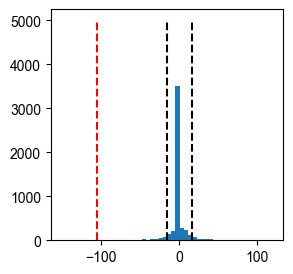

In [233]:
fs(3,3)
realVis = dsPup_precue[dsPup_precue.trlType == 'visual'].iloc[:,:dataN_ds]
realVer = dsPup_precue[dsPup_precue.trlType == 'verbal'].iloc[:,:dataN_ds]

# calcualte the permutated statistic (e.g. F values, t values) and p values
tp = np.array([stats.ttest_ind(realVis.iloc[:,i],realVer.iloc[:,i],
                                nan_policy='omit',) [:2] for i in range(dataN_ds)])

statArr = tp[:,0]
pArr = tp[:,1]

# find the clusters that exceed p value threshold
consGroups_precue = consecutive(np.where(pArr < 0.05)[0], stepsize=1,findSame = False)

#get the p value for each cluster
fsum_precue = [statArr[i].sum() for i in consGroups_precue]
pValue_precue = [sum(fCluster_precue > i)/perms for i in fsum_precue]


plt.hist(fCluster_precue,bins = 50)
plt.vlines(np.percentile(fCluster_precue,95),0,perms,linestyles = 'dashed',color ='black')
plt.vlines(np.percentile(fCluster_precue,5),0,perms,linestyles = 'dashed',color ='black')
plt.vlines([fsum_precue],0,perms,linestyles = 'dashed',color ='r')

precue_sig = [
                (consGroups_precue[i][[0,-1]] * 5500/dataN_ds, 
                 round(1-pValue_precue[i],3))
                for i in np.where(np.asarray(pValue_precue,dtype=float)>0.95)[0]
                ]
print(precue_sig)


[(array([2500., 3000.]), 0.04)]


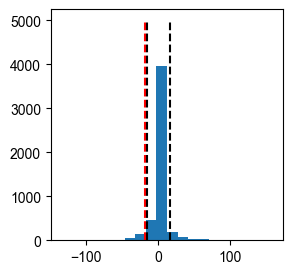

In [234]:
fs(3,3)
dataN_ds = 55
realVis = dsPup_retrocue[dsPup_retrocue.trlType == 'visual'].iloc[:,:dataN_ds]
realVer = dsPup_retrocue[dsPup_retrocue.trlType == 'verbal'].iloc[:,:dataN_ds]

# calcualte the permutated statistic (e.g. F values, t values) and p values
tp = np.array([stats.ttest_ind(realVis.iloc[:,i],realVer.iloc[:,i],
                                nan_policy='omit',) [:2] for i in range(dataN_ds)])

statArr = tp[:,0]
pArr = tp[:,1]

# find the clusters that exceed p value threshold
consGroups_retrocue = consecutive(np.where(pArr < 0.05)[0], stepsize=1,findSame = False)

#get the p value for each cluster
fsum_retrocue = [statArr[i].sum() for i in consGroups_retrocue]
pValue_retrocue = [sum(fCluster_retrocue > i)/perms for i in fsum_retrocue]



plt.hist(fCluster_retrocue,bins = 20)
plt.vlines([fsum_retrocue],0,perms,linestyles = 'dashed',color ='r')
plt.vlines(np.percentile(fCluster_retrocue,95),0,perms,linestyles = 'dashed',color ='black')
plt.vlines(np.percentile(fCluster_retrocue,5),0,perms,linestyles = 'dashed',color ='black')

retrocue_sig = [
                (consGroups_retrocue[i][[0,-1]] * 5500/dataN_ds, 
                 round(1-pValue_retrocue[i],3))
                for i in np.where(np.asarray(pValue_retrocue,dtype=float)>0.95)[0]
                ]
print(retrocue_sig)


In [235]:
precue_T = np.array([0.5,1.5,2.5,3,6]) - 0.5
retrocue_T = np.array([0.5,1.5,2,2.5,3,6]) - 0.5

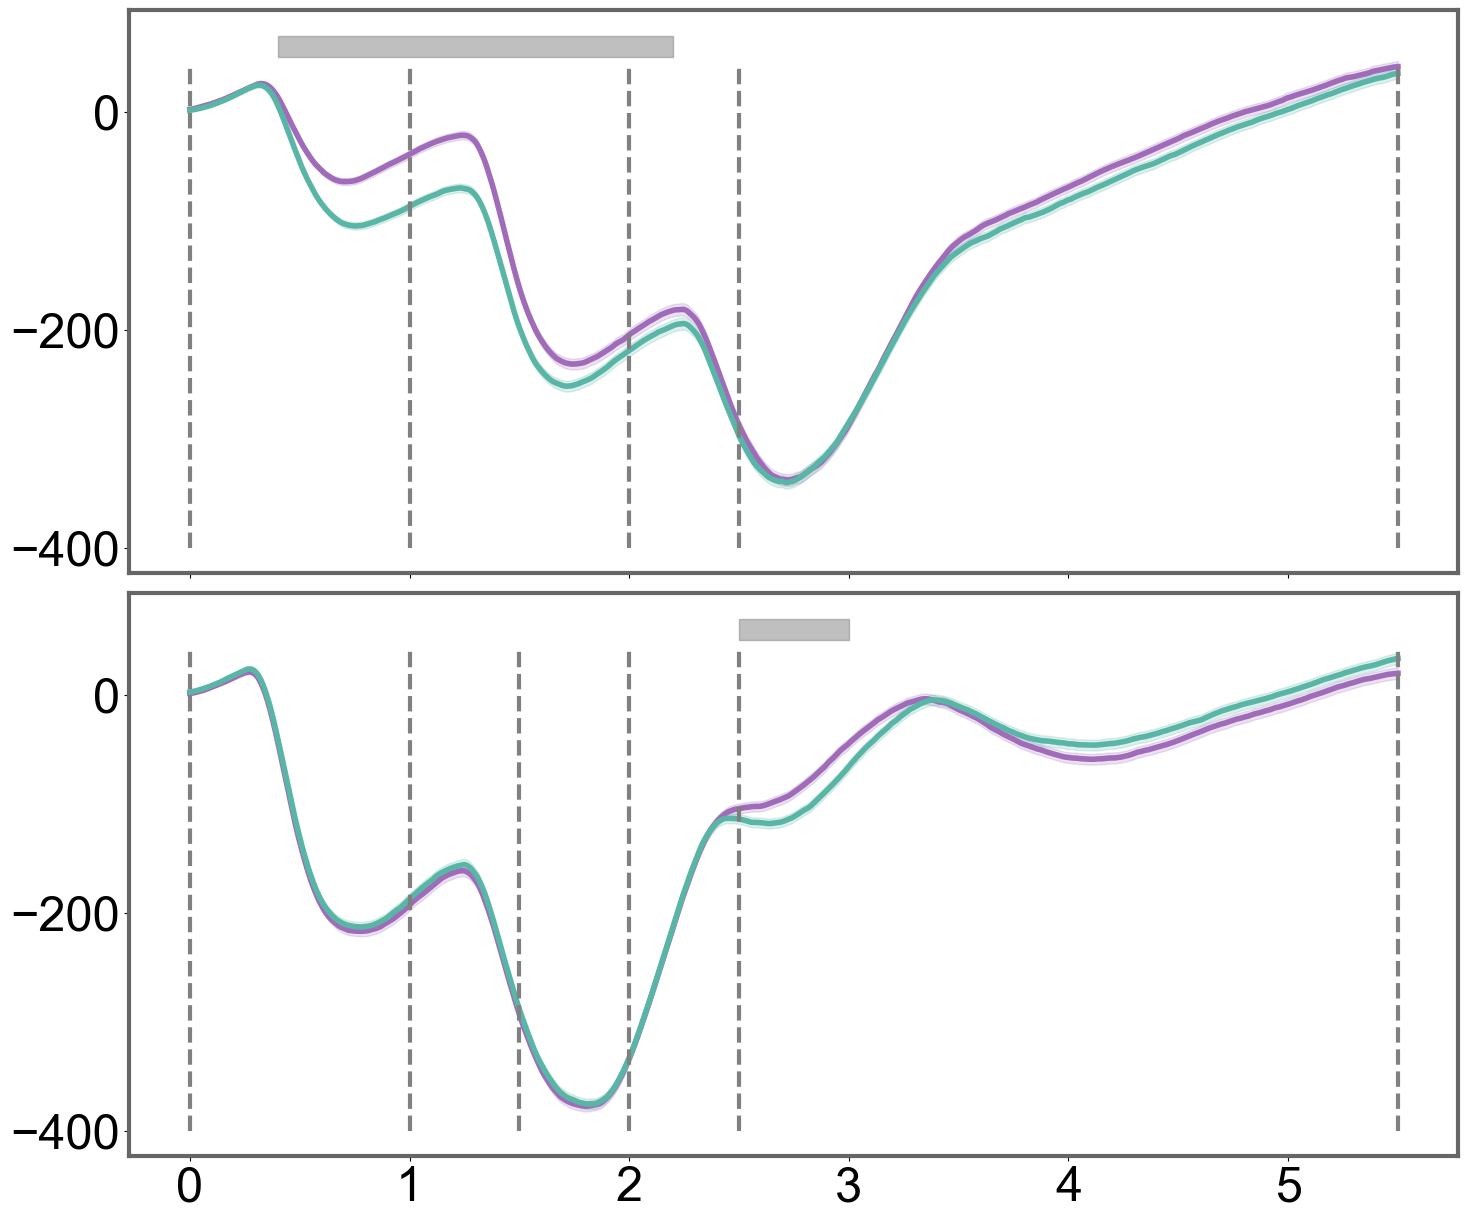

In [236]:
dataN = 5500
xAxis = np.linspace(0,5.5,dataN)
fig,ax = plt.subplots(nrows = 2,figsize = (14,12),sharex=True)

def plot_mean_sem(ax, mean, sderr, colors = ('#a06bb9', '#59b6a6'), linewidths = 4,**kwargs):
    
    for i, color in enumerate(colors):
        smooth_mean = smooth(mean[i,:dataN],**kwargs)
        ax.plot(xAxis, smooth_mean, color = color, linewidth = linewidths)
        ax.fill_between(xAxis, smooth_mean + sderr[i,:dataN], 
                        smooth_mean - sderr[i,:dataN], color = color, alpha = 0.2)

plot_mean_sem(ax[0], pupMean_precue.values, pupSem_precue.values,window_len = 31)
plot_mean_sem(ax[1], pupMean_retrocue.values, pupSem_retrocue.values,window_len = 31)

for i in range(len(precue_sig)):
    ax[0].fill_between(precue_sig[i][0]/1000, 50, 70, color = 'grey', alpha = 0.5)

for i in range(len(retrocue_sig)):
    ax[1].fill_between(retrocue_sig[i][0]/1000, 50, 70, color = 'grey', alpha = 0.5)

ax[0].vlines(precue_T,-400,40,colors = 'grey',linestyles = 'dashed',linewidth = 3)
ax[1].vlines(retrocue_T,-400,40,colors = 'grey',linestyles = 'dashed',linewidth = 3)

plt.tight_layout()
ax[1].tick_params(labelsize=35)
ax[0].tick_params(labelsize=35)

ax[0].yaxis.set_major_locator(ticker.MultipleLocator(200))
ax[1].yaxis.set_major_locator(ticker.MultipleLocator(200))

style_spines(ax[0])
style_spines(ax[1])
